--- Dataset Info ---
<xarray.Dataset> Size: 11GB
Dimensions:                        (y: 12800, x: 14200)
Coordinates:
  * y                              (y) float64 102kB 8.4e+05 ... 1.48e+06
  * x                              (x) float64 114kB 2.255e+06 ... 2.965e+06
    latitude                       (y, x) float64 1GB dask.array<chunksize=(3200, 3550), meta=np.ndarray>
    longitude                      (y, x) float64 1GB dask.array<chunksize=(3200, 3550), meta=np.ndarray>
Data variables:
    DEM                            (y, x) int16 364MB dask.array<chunksize=(3200, 3550), meta=np.ndarray>
    EASTING                        (y, x) float64 1GB dask.array<chunksize=(3200, 3550), meta=np.ndarray>
    NORTHING                       (y, x) float64 1GB dask.array<chunksize=(3200, 3550), meta=np.ndarray>
    SN_DERIVATIVE_2000M_SIGRATIO1  (y, x) float32 727MB dask.array<chunksize=(3200, 3550), meta=np.ndarray>
    SN_DERIVATIVE_500M_SIGRATIO1   (y, x) float32 727MB dask.array<chunksize=

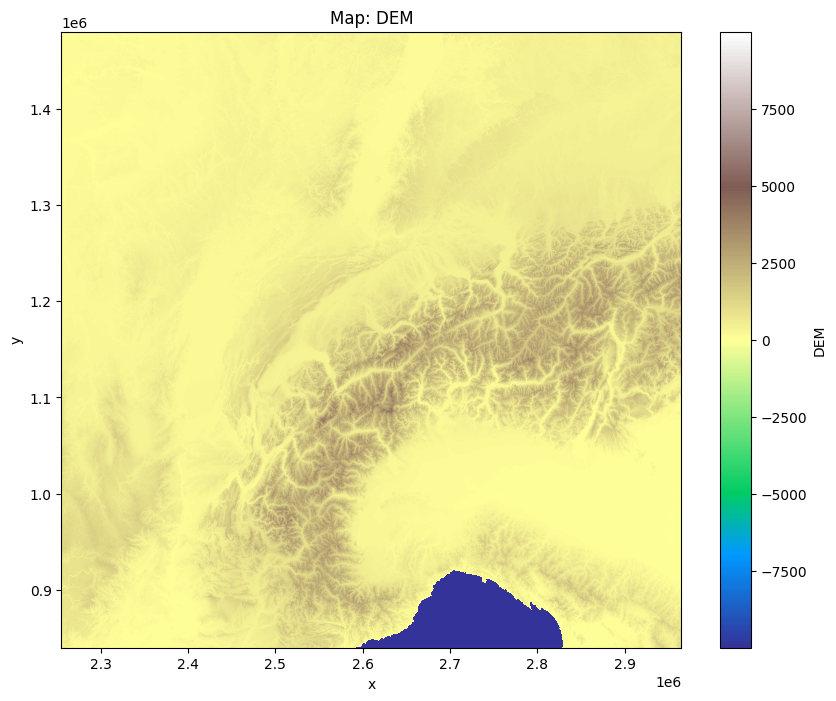

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

dataset_path = Path("./datasets/topo_subset.zarr")

try:
    # Remove zarr.json to stop confusing xarray. It makes it try to use zarr v3.
    json_path = dataset_path / 'zarr.json'
    if json_path.exists():
        # rename file to add .bak
        os.rename(json_path, json_path.with_suffix('.json.bak'))

    # Open the Zarr dataset
    ds = xr.open_zarr(dataset_path, consolidated=True)
    
    print("--- Dataset Info ---")
    print(ds) # This prints the structure to your terminal so you can see variable names
    
    # Automatically grab the first data variable (usually the elevation data)
    var_name = list(ds.data_vars)[0]
    data = ds[var_name]
    
    print(f"\nPlotting variable: {var_name}")

    # Plot the data
    plt.figure(figsize=(10, 8))
    data.plot(cmap='terrain') # 'terrain' is a good color map for DEMs
    plt.title(f"Map: {var_name}")
    plt.show()

except Exception as e:
    print(f"Error: {e}")
    print("Tip: Make sure your path points to the FOLDER, not a file inside it.")

Text(0.5, 1.0, 'Topography Map (Full Resolution)')

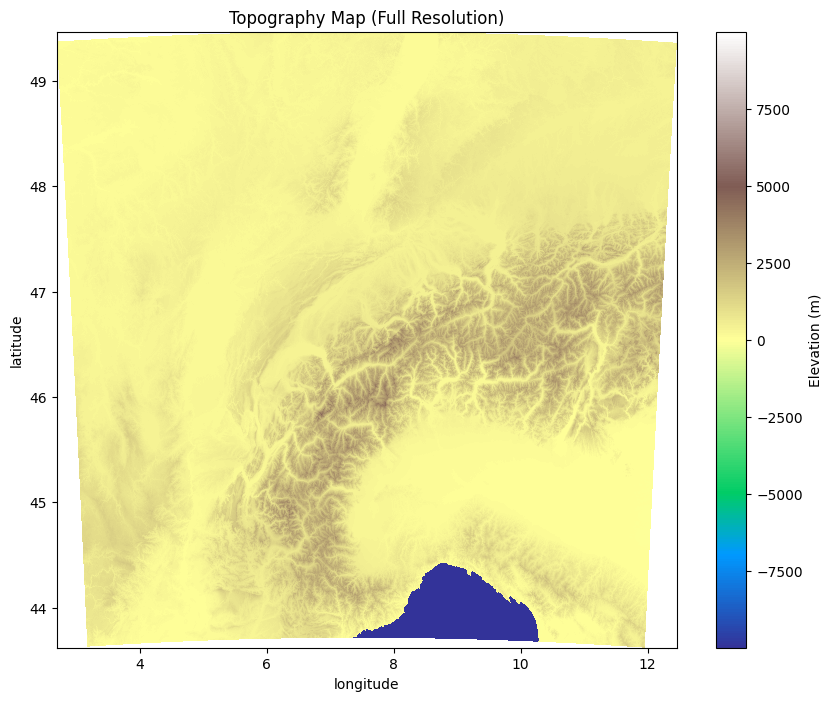

In [2]:
subsample = False

data = ds['DEM']
    
# 2. Downsample for plotting (Take every 10th point)
# This turns 180 million points into ~1.8 million, which is manageable.
subset = data[::10, ::10] if subsample else data


plt.figure(figsize=(10, 8))

subset.plot(
        cmap='terrain',
        # cmap='gist_earth',
        x='longitude', 
        y='latitude', 
        cbar_kwargs={'label': 'Elevation (m)'}
    )
plt.title(f"Topography Map ({'Subsampled' if subsample else 'Full Resolution'})")

<xarray.Dataset> Size: 34kB
Dimensions:    (time: 1, latitude: 51, longitude: 81)
Coordinates:
  * time       (time) datetime64[ns] 8B 2013-08-09T12:00:00
  * latitude   (latitude) float32 204B 49.0 48.9 48.8 48.7 ... 44.2 44.1 44.0
  * longitude  (longitude) float32 324B 4.0 4.1 4.2 4.3 ... 11.7 11.8 11.9 12.0
Data variables:
    z          (time, latitude, longitude) float64 33kB ...
Attributes:
    Conventions:               CF-1.6
    history:                   Fri Jun 12 14:41:56 2020: ncpdq -U geo_1279l4_...
    NCO:                       4.7.2
    nco_openmp_thread_number:  1

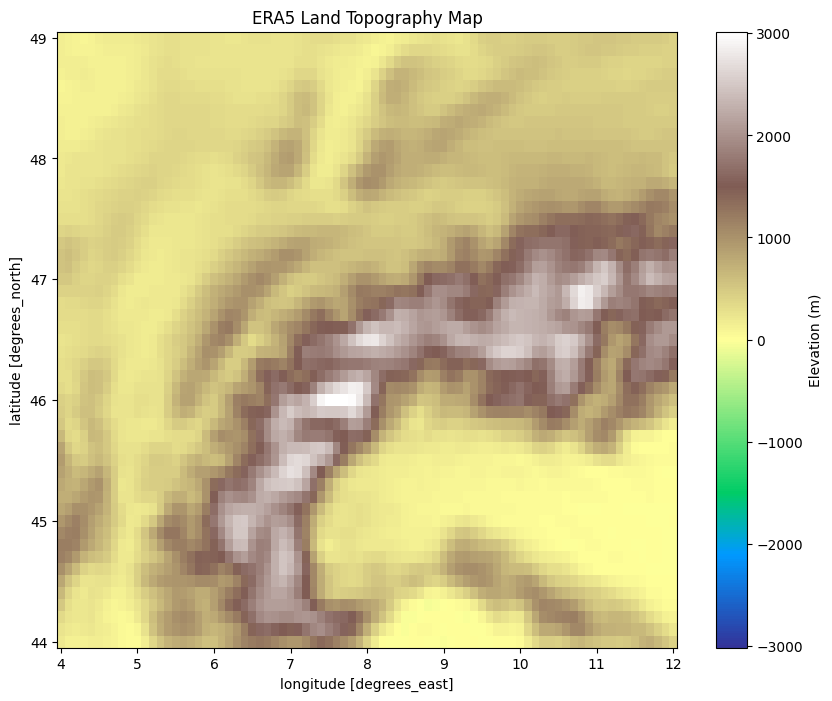

In [9]:
# Geopotential retrieved as follows:
#
# import cdsapi
#
# dataset = "reanalysis-era5-land"
# request = {
#     "variable": ["geopotential"],
#     "data_format": "netcdf",
#     "download_format": "unarchived",
#     "area": [49, 4, 44, 12]
# }
#
# client = cdsapi.Client()
# client.retrieve(dataset, request).download()

# load era5 topo for comparison
era5_path = Path("./datasets/ERA5_Land/geopotential/era5_land_geopotential.nc")
era5_ds = xr.open_dataset(era5_path)
display(era5_ds)

# variable z is geopotential height in m^2/s^2
era5_elevation = era5_ds['z'] / 9.80665  # convert to meters

# Select single time step and drop time dimension for cleaner plotting
era5_elevation = era5_elevation.isel(time=0)

plt.figure(figsize=(10, 8))
era5_elevation.plot(
        x='longitude', 
        y='latitude',
        cmap='terrain',
        cbar_kwargs={'label': 'Elevation (m)'}
    )
plt.title("ERA5 Land Topography Map")
plt.show()